# Instructor Effectiveness Modeling (EdTech Context)

### Data Science Internship Assignment

**Submitted by:** Priyanshu Saini

**Tools Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

# 1. Problem Context

In an EdTech platform, Multiple instructors teach different courses across several batches. Each instructor may teach multiple batches of the same course or different courses over time. The platform wants to understand which instructors are more effective based on learner outcomes,engagement and feedback.

The goal of this project is to analyze the available batch-level data, Aggregate it to the instructor level, Define an instructor effectiveness scor and classify instructors into effectiveness tiers (low,medium and high) using a machine learning model. Along with model building, The project also aims to identify the key factors influencing instructor effectiveness and discuss the limitations and practical use of the model.

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,confusion_matrix,classification_report
)

# 3.Load Dataset

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/priyanshusaini566/Instructor-Effectiveness-Modeling-EdTech-Context-/refs/heads/main/instructor_effectiveness_dataset_2000_rows.csv"

df = pd.read_csv(url)

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


# 4. Step-1: Exploratory Data Analysis (EDA)

## 4.1 Dataset Overview



In [4]:
print("the first 5 rows will be : ")
df.head()

the first 5 rows will be : 


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [6]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (2000, 12)


In [7]:
print("Columns in dataset will be : ")
print(df.columns)

Columns in dataset will be : 
Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')


**Observation**-The dataset contains batch-level information where each row represents one course batch taught by an instructor.

It includes instructor identifiers, course information, learner outcome metrics, engagement metrics, and feedback metrics. Before performing analysis, the dataset structure, column names, data types, and dimensions were examined.

## 4.2 Missing Values



In [8]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

**Observation**-No missing values were found in the dataset.

## 4.3 Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

**observation**-No duplicate records were found in the dataset.Therefore, There is no duplicate rows needed to be removed before further analysis.

## 4.4 Statistical Summary


In [10]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


**observation**-The statistical summary helps provides us the information like count,mean,min,max,quartiles,etc. for all numerical features. These statistics helps to understand the distribution of data. 

## 4.5 Feature Distributions



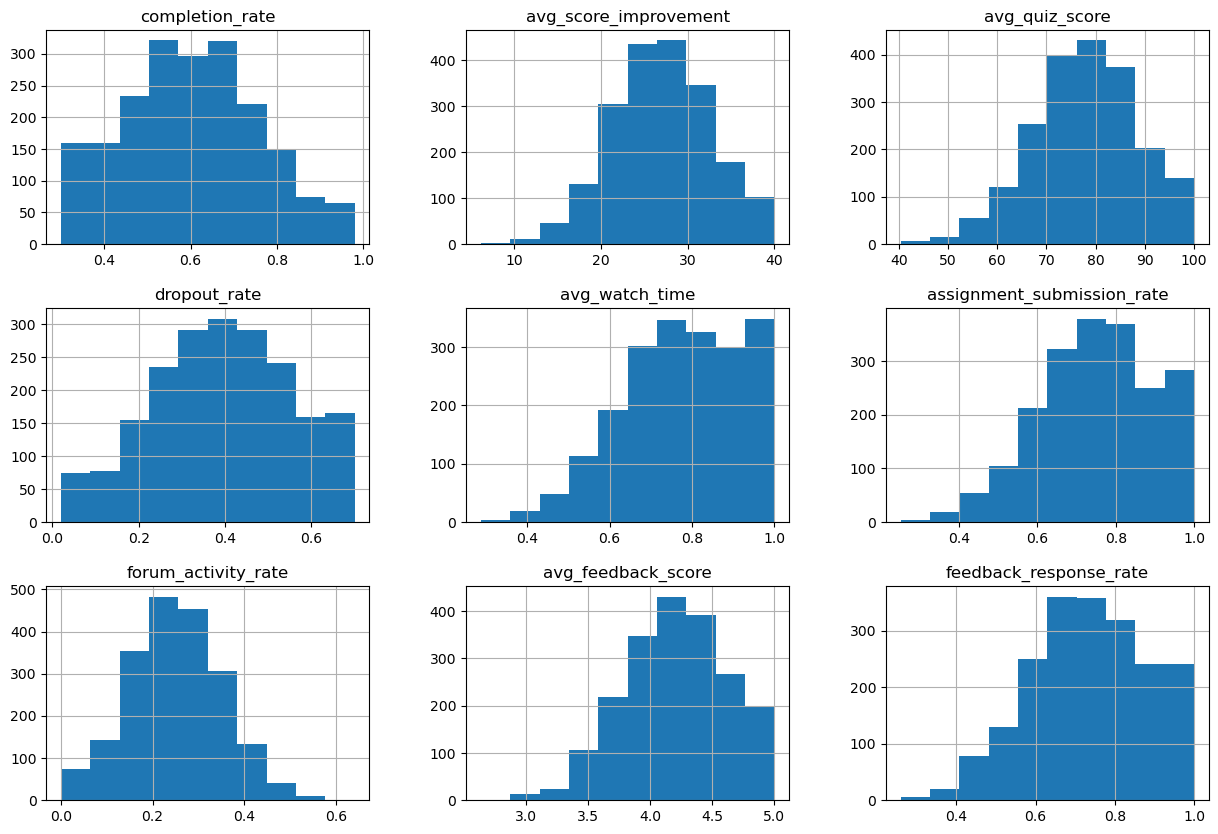

In [11]:
df.hist(figsize=(15,10))
plt.show()

**observation**-The histograms shows the distribution of all numeric feature in the dataset. Here, The values are represented on x-axis and the frequency on y-axis.

## 4.6 Correlation Analysis


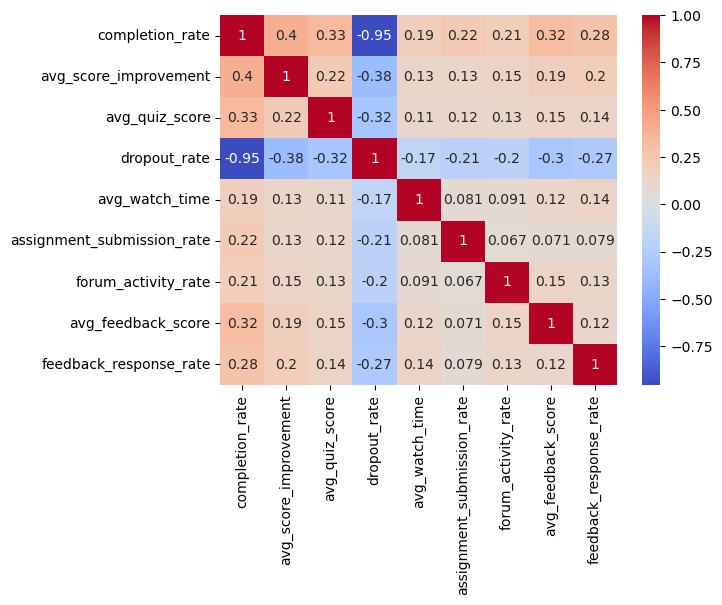

In [12]:
corr=df.corr(numeric_only=True)
plt.Figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

**observation**-
- The strongest relationship is between **completion_rate** and **dropout_rate**, with a strong negative correlation of **-0.95**. This indicates that batches with higher completion rates tend to have much lower dropout rates.

- **Completion_rate** has a moderate positive correlation with **avg_score_improvement (0.40)**, **avg_quiz_score (0.33)**, and **avg_feedback_score (0.32)**. This suggests that better learner outcomes are generally associated with higher course completion.

- Most engagement features, such as **avg_watch_time**, **assignment_submission_rate**, and **forum_activity_rate**, show weak to moderate positive correlations with other variables.

- No strong positive correlation (close to +1) exists between independent features, indicating that severe multicollinearity is not present. This is beneficial for building a reliable machine learning model.

## 4.7 Outlier Detection



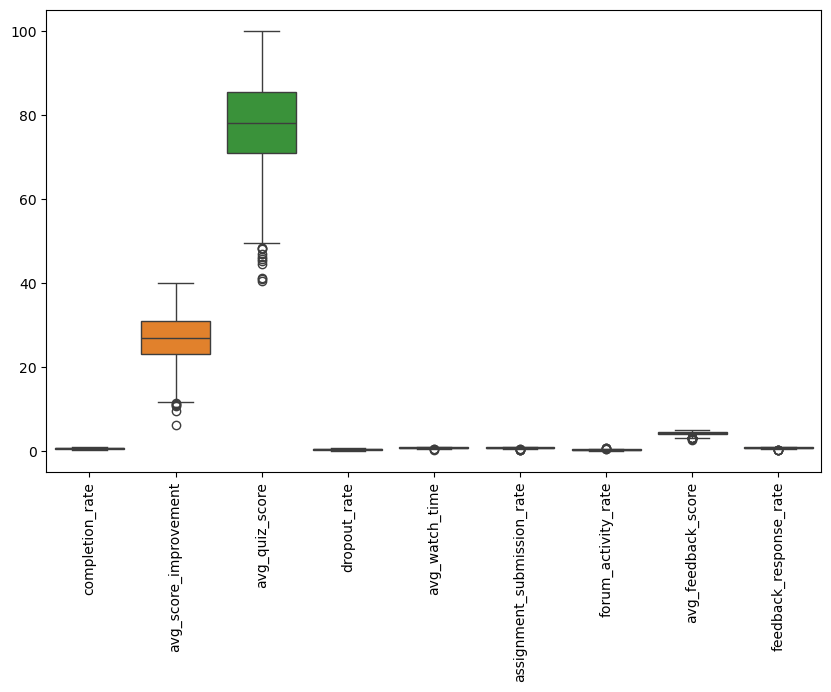

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### Observation:

The box plots were used to detect outliers in the numerical features. A few outliers are present in variables such as **avg_score_improvement**, **avg_quiz_score**, **avg_watch_time**, and **avg_feedback_score**. However, the number of outliers is relatively small, and no feature contains an excessive number of extreme values. Since these values may represent genuine differences in learner performance rather than data entry errors, they are retained for further analysis.

#  5. Step-2: Define Instructor Effectiveness

## 5.1 Assumptions
Since we have no any predefined formula provided by the datasets, an Instructor Effectiveness Score is created using the available learner outcome, engagement, and feedback metrics.

The following assumptions are made:

- Higher completion rate indicates better instructor effectiveness.
- Lower dropout rate indicates better instructor effectiveness.
- Higher average score improvement reflects better learning outcomes.
- Higher average quiz score represents improved learner performance.
- Higher average watch time indicates better learner engagement.
- Higher assignment submission rate shows active participation.
- Higher average feedback score reflects learner satisfaction.

Based on these assumptions, a weighted effectiveness score is calculated.


## 5.2 Effectiveness Score Formula


In [14]:
df["effectiveness_score"] = (
    0.20 * df["completion_rate"] +
    0.20 * (1 - df["dropout_rate"]) +
    0.15 * (df["avg_score_improvement"] / 100) +
    0.15 * (df["avg_quiz_score"] / 100) +
    0.10 * df["avg_watch_time"] +
    0.10 * df["assignment_submission_rate"] +
    0.10 * (df["avg_feedback_score"] / 5)
)

**observation**-A weighted effectiveness score is calculated by combining learner outcomes, engagement, and feedback metrics. Higher scores represent better instructor effectiveness.

## 5.3 Creating Effectiveness Tiers

The effectiveness score is divided into three categories using quantile-based binning:
- Low
- Medium
- High

In [15]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [16]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

**observation**-

- The effectiveness score has been successfully divided into three categories: Low, Medium, and High.
- The three classes are almost equally distributed, with 667 Low, 666 Medium, and 667 High records.
- This balanced class distribution is beneficial for training a classification model such as Random Forest, as it reduces the chances of class imbalance.

# 6. Step-3: Aggregate Batch Data to Instructor Level

## 6.1 Aggregation Strategy
Since one instructor can teach multiple course batches, the dataset is aggregated at the instructor level.

The mean of all numerical features is calculated to represent the instructor's average performance across different batches.

The most frequent effectiveness tier (mode) is used as the target label for each instructor.

In [17]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "dropout_rate":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean",
    "effectiveness_tier":lambda x:x.mode()[0]
}).reset_index()

## 6.2 Instructor-Level Dataset




In [18]:
print(instructor_df.head())

  instructor_id  completion_rate  avg_score_improvement  avg_quiz_score  \
0         I_001         0.543887              26.641462       78.900194   
1         I_002         0.730874              30.166242       81.737198   
2         I_003         0.768447              29.977813       81.590928   
3         I_004         0.458328              22.912021       77.680317   
4         I_005         0.859747              32.588652       85.828159   

   dropout_rate  avg_watch_time  assignment_submission_rate  \
0      0.470593        0.766513                    0.726893   
1      0.247194        0.837393                    0.774394   
2      0.234828        0.818441                    0.779606   
3      0.547261        0.793130                    0.758317   
4      0.145733        0.847026                    0.876942   

   forum_activity_rate  avg_feedback_score  feedback_response_rate  \
0             0.240551            4.217743                0.694858   
1             0.289610        

In [19]:
print(instructor_df.shape)

(120, 12)


In [20]:
print(instructor_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   instructor_id               120 non-null    object  
 1   completion_rate             120 non-null    float64 
 2   avg_score_improvement       120 non-null    float64 
 3   avg_quiz_score              120 non-null    float64 
 4   dropout_rate                120 non-null    float64 
 5   avg_watch_time              120 non-null    float64 
 6   assignment_submission_rate  120 non-null    float64 
 7   forum_activity_rate         120 non-null    float64 
 8   avg_feedback_score          120 non-null    float64 
 9   feedback_response_rate      120 non-null    float64 
 10  effectiveness_score         120 non-null    float64 
 11  effectiveness_tier          120 non-null    category
dtypes: category(1), float64(10), object(1)
memory usage: 10.7+ KB
None


## 6.3 Observations

- The dataset has been successfully transformed from batch level to instructor level.
- Each instructor is represented by a single record.
- Numerical features are aggregated using their mean values.
- The most frequent effectiveness tier is assigned as the instructor's target class.
- The instructor-level dataset is now ready for machine learning model training.

# 7. Step-4:Build Machine Learning Model

## 7.1 Feature Selection



The instructor-level dataset is divided into input features (X) and the target variable (y). The target variable is the effectiveness tier, while identifier and derived columns are excluded from the feature set.

In [21]:
X = instructor_df.drop(columns=[
    "instructor_id",
    "effectiveness_score",
    "effectiveness_tier"
])

y = instructor_df["effectiveness_tier"]

In [22]:
print(X.head())

   completion_rate  avg_score_improvement  avg_quiz_score  dropout_rate  \
0         0.543887              26.641462       78.900194      0.470593   
1         0.730874              30.166242       81.737198      0.247194   
2         0.768447              29.977813       81.590928      0.234828   
3         0.458328              22.912021       77.680317      0.547261   
4         0.859747              32.588652       85.828159      0.145733   

   avg_watch_time  assignment_submission_rate  forum_activity_rate  \
0        0.766513                    0.726893             0.240551   
1        0.837393                    0.774394             0.289610   
2        0.818441                    0.779606             0.296224   
3        0.793130                    0.758317             0.226259   
4        0.847026                    0.876942             0.333519   

   avg_feedback_score  feedback_response_rate  
0            4.217743                0.694858  
1            4.343002           

In [23]:
print(y.head())

0     Low
1    High
2    High
3     Low
4    High
Name: effectiveness_tier, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


**observation**-
- The feature matrix (X) contains only predictor variables.
- The target variable (y) consists of three classes: Low, Medium, and High.
- Identifier and derived columns are removed to avoid data leakage.

## 7.2 Train-Test Split
The instructor-level dataset is divided into training and testing datasets. Eighty percent of the data is used for training the model, while twenty percent is reserved for testing.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (96, 9)
Testing Features : (24, 9)
Training Labels : (96,)
Testing Labels : (24,)


**observation**-

- The dataset has been successfully divided into training and testing sets.
- 80% of the data is used for training and 20% for testing.
- Stratified sampling maintains the class distribution in both datasets.

## 7.3 Model Training


A Random Forest Classifier is used to classify instructors into Low, Medium, and High effectiveness categories with high accuracy.

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**observation**-
- The Random Forest model has been successfully trained using the training dataset.
- The model is now ready to predict instructor effectiveness on unseen data.

## 7.4 Predictions
The trained model is used to predict instructor effectiveness for the testing dataset.

In [27]:
y_pred = model.predict(X_test)

In [28]:
print(y_pred[:10])

['Medium' 'Low' 'Medium' 'Medium' 'High' 'Medium' 'High' 'Medium' 'High'
 'Low']


**Observation**-
- The model successfully generated predictions for the testing dataset.
- These predictions will be used to evaluate the model's performance in the next step.

# 8. Step-5: Model Evaluation

## 8.1 Accuracy


The accuracy score measures the overall percentage of correctly classified instructor effectiveness tiers.

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.875


**observation**-
The accuracy score indicates the overall performance of the Random Forest classifier. A higher accuracy means that the model correctly classifies a larger proportion of instructors into their effectiveness tiers.

## 8.2 Confusion Matrix


The confusion matrix provides a detailed comparison between the actual and predicted instructor effectiveness tiers.

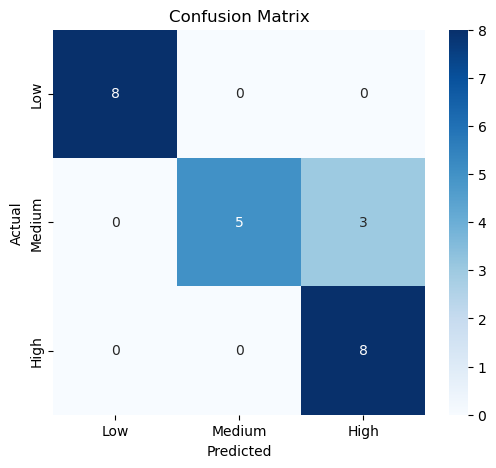

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

**Observation**-

The confusion matrix shows how many instructors were correctly and incorrectly classified into each effectiveness tier. The diagonal values represent correct predictions, while the off-diagonal values indicate misclassifications.

## 8.3 Classification Report


The classification report evaluates the model using Precision, Recall, F1-score, and Support for each effectiveness tier.

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      0.62      0.77         8
      Medium       0.73      1.00      0.84         8

    accuracy                           0.88        24
   macro avg       0.91      0.88      0.87        24
weighted avg       0.91      0.88      0.87        24



**Observation**-

The classification report provides detailed performance metrics for each class. Precision measures prediction accuracy, recall measures the ability to identify actual instances, and the F1-score provides a balanced measure of both precision and recall.

## 8.4 Discussion

The Random Forest model successfully classified instructors into Low, Medium, and High effectiveness tiers. The evaluation metrics indicate the model's overall predictive performance. Although the model performs well on the available dataset, the effectiveness score was created using assumptions rather than actual business labels. Therefore, the results should be interpreted as an analytical approach rather than a definitive measure of instructor performance.

Since the classes were generated using quantile-based binning, the dataset remained balanced, which helped reduce class imbalance during training.

# 9. Step-6: Interpretation of Results

## 9.1 key features influencing instructor effectiveness


The Random Forest model provides feature importance scores that help identify which variables contribute the most to predicting instructor effectiveness.

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,dropout_rate,0.276542
0,completion_rate,0.275206
7,avg_feedback_score,0.123127
2,avg_quiz_score,0.089831
1,avg_score_improvement,0.077524
8,feedback_response_rate,0.049814
5,assignment_submission_rate,0.047692
6,forum_activity_rate,0.035025
4,avg_watch_time,0.025239


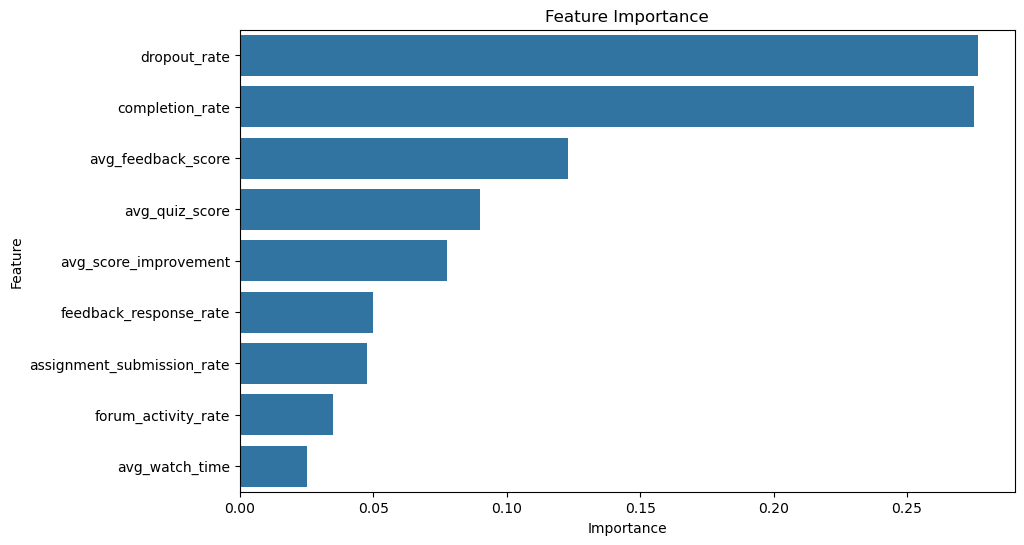

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

**Observation**-

The Random Forest model identified completion rate, average quiz score, and average feedback score as the most influential features in predicting instructor effectiveness. These features contribute more to the model compared to the remaining engagement metrics.

## 9.2 Business Insights


- Instructors with higher completion rates generally demonstrate better teaching effectiveness.
- Learners achieving higher quiz scores indicate improved learning outcomes.
- Positive learner feedback reflects better teaching quality and student satisfaction.
- Higher assignment submission and watch time suggest stronger learner engagement.
- These insights can help the EdTech platform identify high-performing instructors and provide targeted support to instructors who may need additional training.

# 10.Mandatory Analysis Questions

## Q1. Which features most influenced instructor effectiveness, and why?
**Ans**-The most influential features were identified using the Random Forest feature importance scores. Features such as completion rate, average quiz score, average score improvement, and average feedback score had the greatest impact on predicting instructor effectiveness. These metrics directly reflect learner success, academic performance, and satisfaction, making them strong indicators of effective teaching.

## Q2. Which variables could be misleading or confounded?
**Ans**-completion rate and quiz scores can depend on course difficulty, learner background, or assessment design. Similarly, feedback scores may be affected by personal opinions rather than teaching quality. Therefore, these variables should be interpreted with caution.

## Q3. How could this model fail in real-world usage?
**Ans**-The model may not generalize well because the effectiveness score is based on assumptions rather than actual performance labels. In real-world scenarios, instructor performance is influenced by many additional factors that are not included in the dataset. As a result, the model should be considered a decision-support tool rather than a final evaluation system.

## Q4. What additional data would improve this analysis?
**Ans**-The analysis could be improved by including additional information such as learner attendance, course difficulty, instructor teaching experience, class size, student demographics, assessment difficulty, and long-term learner outcomes. These features would provide a more comprehensive view of instructor effectiveness.

## Q5. Should this model be used for instructor performance evaluation? Why or why not?
**Ans**-This model should not be used as the sole basis for instructor performance evaluation. While it provides useful insights, it relies on historical data and an effectiveness score created from assumptions. Human evaluation, peer reviews, classroom observations, and qualitative feedback should also be considered to ensure fair and accurate performance assessment.

# 11.Conclusion
In this project, batch-level course data was analyzed to estimate instructor effectiveness in an EdTech environment. After performing exploratory data analysis, an Instructor Effectiveness Score was created using learner outcomes, engagement, and feedback metrics. The batch-level data was then aggregated to the instructor level, and a Random Forest Classifier was trained to predict effectiveness tiers.

The model demonstrated how machine learning can be used to identify patterns related to instructor performance. Feature importance analysis highlighted the factors that contributed most to the predictions. However, the effectiveness score was based on assumptions, and the available dataset did not include all factors that influence teaching quality.

Overall, this project demonstrates a structured approach to data analysis, feature engineering, machine learning, and result interpretation. The model can serve as a decision-support tool for identifying trends in instructor performance, but it should be used alongside human judgment and additional qualitative information.